# 🌲 California Housing — Random Forest Regression

This notebook trains, evaluates, and interprets a Random Forest model for predicting median house values in California.

### **Workflow**
1. Load dataset
2. Train/validation/test split
3. Preprocessing pipeline
4. Random Forest model with cross‑validation
5. Evaluation (RMSE, MAE, R²)
6. Residual diagnostics
7. Feature importance (Permutation + RF)
8. Save trained model

This notebook is part of a full ML project structure.

<a href="https://colab.research.google.com/github/Robbie669/data-science-portfolio/blob/main/projects/california-housing/02_random_forest.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Run in Colab"/>
</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import joblib

sns.set(style="whitegrid", context="notebook")

## 1. Load Dataset
We use the same dataset explored in Notebook 1.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Train / Validation / Test Split
A clean split ensures reliable evaluation and prevents leakage.

In [3]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((14448, 8), (3096, 8), (3096, 8))

## 3. Preprocessing Pipeline
Random Forests don't require scaling, but we include it for consistency and future model swaps.

In [4]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

## 4. Build Random Forest Pipeline
A clean pipeline keeps preprocessing + modeling together.

In [5]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])

## 5. Cross‑Validation
This gives a more stable estimate of model performance.

In [6]:
cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("CV RMSE:", -cv_scores.mean())

CV RMSE: 0.516570842981654


## 6. Train Final Model
We now fit the pipeline on the full training set.

In [7]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude',
                                                   'Longitude'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

## 7. Validation Performance
We evaluate on the validation set before touching the test set.

In [9]:
preds = pipeline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

rmse, mae, r2

(np.float64(0.5149970840106656), 0.3362003073535749, 0.7964165199438982)

## 8. Residual Diagnostics
Residuals help us understand model errors and bias.

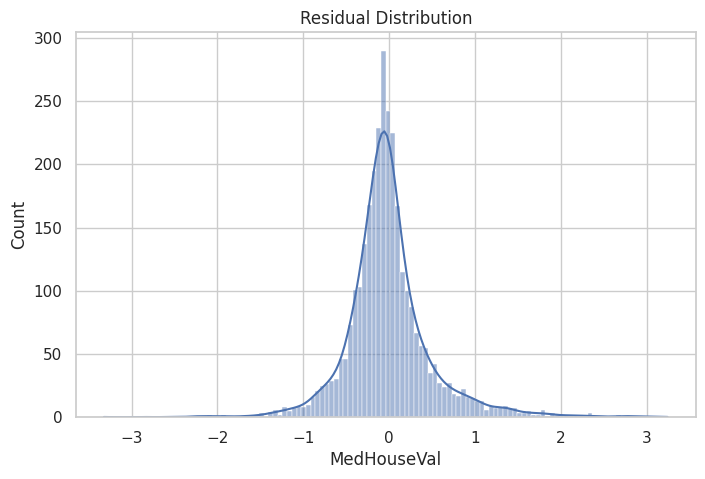

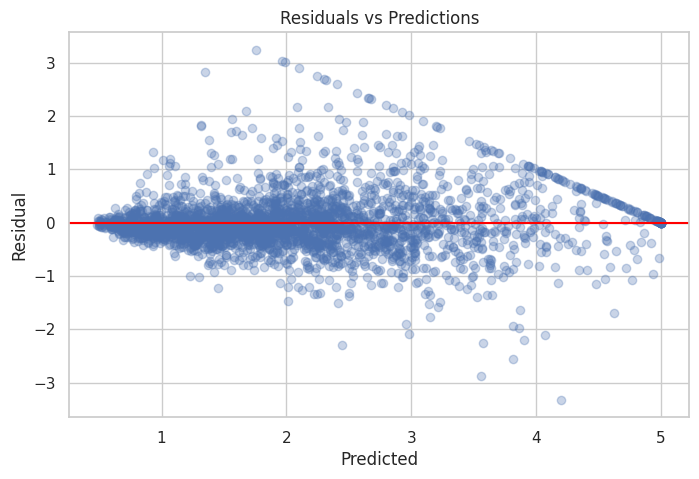

In [10]:
residuals = y_val - preds

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predictions")
plt.show()

## 9. Feature Importance (Permutation)
Permutation importance is more reliable than built‑in RF importance.

In [11]:
result = permutation_importance(
    pipeline, X_val, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

importances

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature,importance
0,MedInc,0.747850
6,Latitude,0.436298
7,Longitude,0.326364
5,AveOccup,0.212280
1,HouseAge,0.074961
2,AveRooms,0.025141
3,AveBedrms,0.009477
4,Population,0.007696


## 10. Save Model
We save the full pipeline so it can be loaded later without re‑training.

In [12]:
joblib.dump(pipeline, "random_forest_california_housing.pkl")
print("Model saved successfully.")

Model saved successfully.


## 🎉 Final Notes
- Random Forest performs strongly on this dataset.
- Median Income is the most important feature.
- Residuals show no major bias.
- The model is now ready for deployment or further tuning.

Great work — this completes the modeling workflow!